In [1]:
import os
import time
# os.environ["CUDA_VISIBLE_DEVICES"] = "0,1"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.95"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'

# #使用 CPU 平台
# os.environ['JAX_PLATFORM_NAME'] = 'cpu'

import jax
import jax.numpy as jnp
import jax.tree_util as jtu


from flax import linen as nn
from flax.training import train_state
from flax import serialization
from flax import traverse_util

import optax
import matplotlib.pyplot as plt

from model import *

key = jax.random.PRNGKey(0)
print(f"JAX device: {jax.devices()}")

JAX device: [CudaDevice(id=0)]


In [2]:
# %pwd

In [3]:
config = ModelConfig(Dim=2,
                     l = jnp.array([[1/3]*2,
                                    [1/5]*2,
                                    [1/7]*2,]),
                     
                     hidden_layers_BNN = 256,
                     N_basis = 512,

                     sigma_B = 5,
                     theta_size = 128,

                     Sample_size = 256,
                     function = 'Poisson',
                     function_K = 0.01,
                     remark='GP_R',)

# config.save(config.out_dir+config.remark+".pkl")
# config = ModelConfig.load("None.pkl")
config

ModelConfig(Dim=2, l=Array([[0.33333334, 0.33333334],
       [0.2       , 0.2       ],
       [0.14285715, 0.14285715]], dtype=float32), sigma=Array([[3., 3.],
       [5., 5.],
       [7., 7.]], dtype=float32), hidden_layers_BNN=256, N_basis=512, Sample_size=256, sigma_B=5, theta_size=128, BranchNet_features=[512, 512, 512, 512, 512], TrunkNet_features=[512, 512, 512, 512, 512], function='Poisson', function_K=0.01, remark='GP_R', out_dir='./out/')

In [4]:
theta = jnp.linspace(0,jnp.pi*2,config.theta_size,False)[...,None]
thetaP = jnp.linspace(0,jnp.pi*2,config.theta_size*6,False)[...,None]

In [5]:
G_func = BNN_sin
# G_func = EXP_BNN_sin

In [6]:
# print(f'u std {data_u_.shape}')
# print(f'u std {data_u_.std(0).mean():.2f}')
# print(f'f std {data_f_.std(0).mean():.2f}')
# print(f'K ref {1/(data_f_.std(0).mean()/(config.function_K)):.5f}')

In [7]:
@jax.jit
def get_r(key, sigma_B, theta):
    r = BNN_boundary(key, sigma_B, theta,sample_size = config.Sample_size, in_dim = config.Dim, hidden_layers = config.hidden_layers_BNN, out_dim = 1)[...,0]
    return 0.45*jax.nn.tanh(0.3*r)+0.55

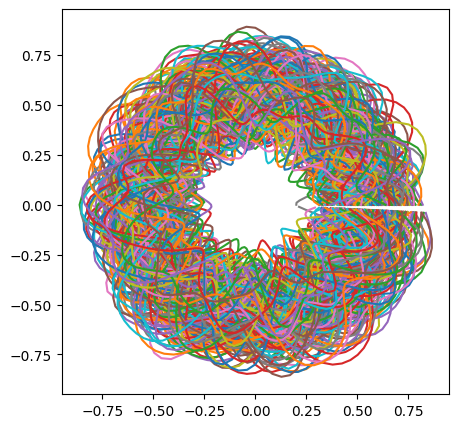

(256, 128, 2)

In [8]:
key, subkey = jax.random.split(key)
r = get_r(subkey,config.sigma_B,theta)

xx = jnp.cos(theta[...,0])*r
yy = jnp.sin(theta[...,0])*r
XY = jnp.stack([xx,yy],-1)


plt.figure(figsize=(5, 5))
Ns = 10
plt.plot(XY[:500,...,0].T,XY[:500,...,1].T)
plt.show()
XY.shape

In [9]:
@jax.jit
def sample(key, single_sigma, key_x_in):

    n_points = 100
    key_x_in1, key_x_in2 = jax.random.split(key_x_in)
    theta_R = jax.random.uniform(key_x_in1, shape=(n_points, 1), minval=0.0, maxval=jnp.pi*2)
    rate_R = jax.random.uniform(key_x_in2, shape=(10, n_points), minval=0.0, maxval=1)**0.5



    key, subkey = jax.random.split(key)
    r = get_r(subkey,config.sigma_B,theta)
    r_R = get_r(subkey,config.sigma_B,theta_R)

    
    ##########################################################################################
    xx = jnp.cos(theta[...,0])*r
    yy = jnp.sin(theta[...,0])*r
    x_B = jnp.stack([xx,yy],-1)
    

    r0 = jnp.linspace(0.005,1,32)[:,None]**(0.8)
    xx0 = jnp.cos(theta[...,0])*r0
    yy0 = jnp.sin(theta[...,0])*r0
    x_0 = jnp.stack([xx0,yy0],-1).reshape(-1,2)[None,...].repeat(config.Sample_size,0)
    
    xx1 = jnp.cos(theta[...,0])*r0*r[:,None,:]
    yy1 = jnp.sin(theta[...,0])*r0*r[:,None,:]
    x_1 = jnp.stack([xx1,yy1],-1).reshape(config.Sample_size,-1,2)

    ###########################################################################################

    xx = (jnp.cos(theta_R[...,0])*rate_R)*r_R[:,None,:]
    yy = (jnp.sin(theta_R[...,0])*rate_R)*r_R[:,None,:]
    x_R1 = jnp.stack([xx,yy],-1).reshape(config.Sample_size,-1,2)
    
    xx = (jnp.cos(theta_R[...,0])*rate_R)
    yy = (jnp.sin(theta_R[...,0])*rate_R)
    x_R0 = jnp.stack([xx,yy],-1)[None,...].repeat(config.Sample_size,0).reshape(config.Sample_size,-1,2)
    
    ###########################################################################################

    key, subkey = jax.random.split(key)
    u_B, _ = func(G_func(subkey, single_sigma, x_B, sample_size = config.Sample_size, in_dim = config.Dim, hidden_layers = config.hidden_layers_BNN, out_dim = 1), config.function_K, config.function)
    u_area, f_area = func(G_func(subkey, single_sigma, x_1, sample_size = config.Sample_size, in_dim = config.Dim, hidden_layers = config.hidden_layers_BNN, out_dim = 1), config.function_K, config.function)
    u_area_R, f_area_R = func(G_func(subkey, single_sigma, x_R1, sample_size = config.Sample_size, in_dim = config.Dim, hidden_layers = config.hidden_layers_BNN, out_dim = 1), config.function_K, config.function)
    # k_u_area  = jnp.dot(u_area[...,0], pod_modes)
    # k_f_area  = jnp.dot(f_area[...,0], pod_modes)
    
    return x_B, u_B, x_0, x_1, u_area, f_area, x_R0, x_R1, u_area_R, f_area_R
    
@jax.jit
def Sample_list(key):
    key, key_x_in = jax.random.split(key)

    
    # 1. 先收集所有样本
    samples = []
    for i in config.sigma:
        key, subkey = jax.random.split(key)
        res = sample(subkey, i, key_x_in)  # 返回 (x_B, x_0, x_1, u_B, u_area, f_area)
        samples.append(res)
    
    # 2. 使用 tree_map 一键拼接
    # *samples 会解包列表，tree_map 会把所有 tuple 对应位置的数组传给 lambda
    final_res = jtu.tree_map(lambda *args: jnp.concatenate(args, axis=0), *samples)
    
    return final_res

In [10]:
key, subkey = jax.random.split(key)
x_B, u_B, x_0, x_1, u_area, f_area, x_R0, x_R1, u_area_R, f_area_R = Sample_list(subkey)

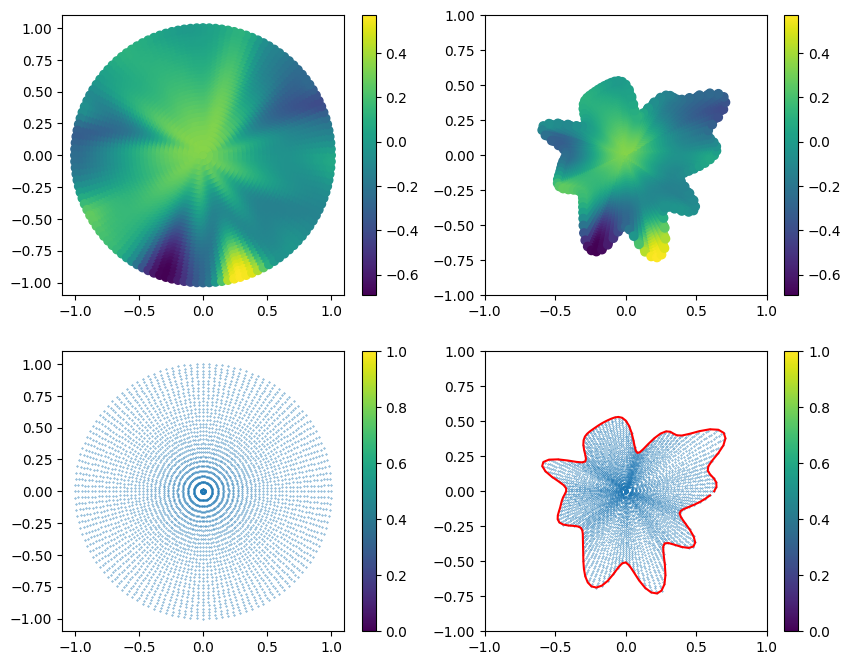

In [11]:
index = 1

plt.figure(figsize=(10,8))
plt.subplot(2,2,1)
# plt.title('predict')

plt.scatter(x_0[index,:,0],x_0[index,:,1],c = f_area[index,:,0])
# plt.plot(x_B[index,:,0],x_B[index,:,1],'r')
plt.colorbar()


plt.subplot(2,2,2)
# plt.title('ref')
plt.scatter(x_1[index,:,0],x_1[index,:,1],c = f_area[index,:,0])
# plt.plot(x_B[index,:,0],x_B[index,:,1],'r')
plt.xlim([-1,1])
plt.ylim([-1,1])
plt.colorbar()

plt.subplot(2,2,3)
# plt.title('predict')

plt.scatter(x_0[index,:,0],x_0[index,:,1],s=0.1)
# plt.plot(x_B[index,:,0],x_B[index,:,1],'r')
plt.colorbar()


plt.subplot(2,2,4)
# plt.title('ref')
plt.scatter(x_1[index,:,0],x_1[index,:,1],s=0.1)
plt.plot(x_B[index,:,0],x_B[index,:,1],'r')
plt.xlim([-1,1])
plt.ylim([-1,1])

plt.colorbar()

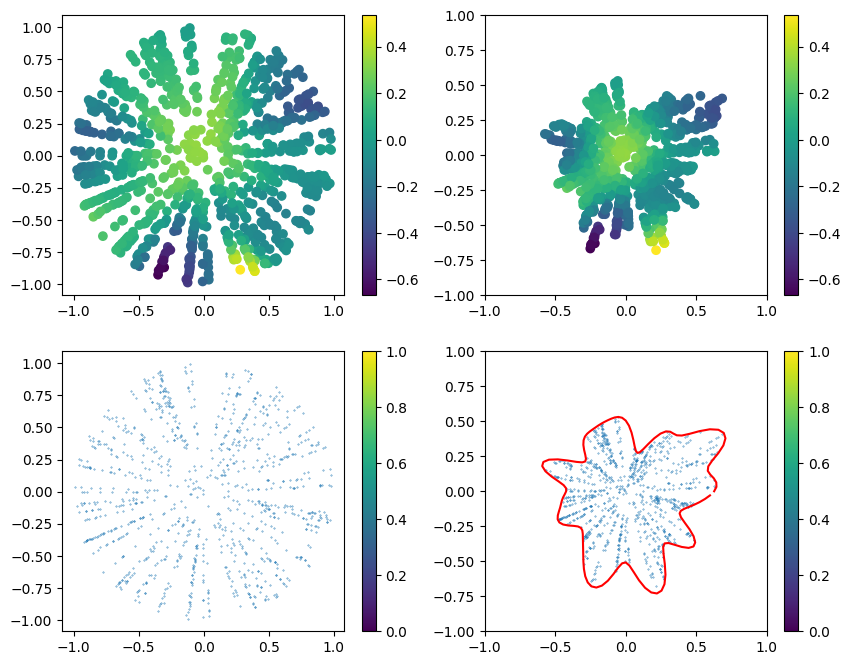

In [12]:
plt.figure(figsize=(10,8))
plt.subplot(2,2,1)
# plt.title('predict')

plt.scatter(x_R0[index,:,0],x_R0[index,:,1],c = f_area_R[index,:,0])
# plt.plot(x_B[index,:,0],x_B[index,:,1],'r')
plt.colorbar()


plt.subplot(2,2,2)
# plt.title('ref')
plt.scatter(x_R1[index,:,0],x_R1[index,:,1],c = f_area_R[index,:,0])
# plt.plot(x_B[index,:,0],x_B[index,:,1],'r')
plt.xlim([-1,1])
plt.ylim([-1,1])
plt.colorbar()

plt.subplot(2,2,3)
# plt.title('predict')

plt.scatter(x_R0[index,:,0],x_R0[index,:,1],s=0.1)
# plt.plot(x_B[index,:,0],x_B[index,:,1],'r')
plt.colorbar()


plt.subplot(2,2,4)
# plt.title('ref')
plt.scatter(x_R1[index,:,0],x_R1[index,:,1],s=0.1)
plt.plot(x_B[index,:,0],x_B[index,:,1],'r')
plt.xlim([-1,1])
plt.ylim([-1,1])

plt.colorbar()

# Compute POD On Cirle

pod sample size 76800
Reconstruction Err u3.98e-03
Reconstruction Err f6.73e-03
Pod_basis 512
f std 0.91
K ref 0.01099


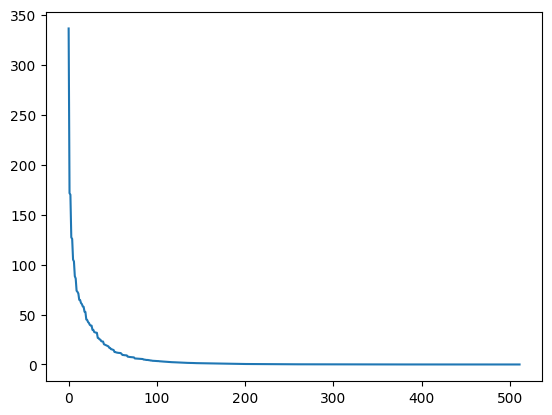

In [13]:
data_f_list = []

N_D = 100
for i in range(N_D):
    key, subkey = jax.random.split(key)
    x_B, u_B, x_0, x_1, u_area, f_area, x_R0, x_R1, u_area_R, f_area_R = Sample_list(subkey)
    data_f_list.append(f_area[...,0])
    
data_f = jnp.concatenate(data_f_list,0)

M = N_D*config.Sample_size*len(config.sigma)
print(f'pod sample size {M}')

U = data_f.T
mean_func = jnp.mean(U, axis=1, keepdims=True)*0
U_centered = U - mean_func

u, s, vh = jnp.linalg.svd(U_centered, full_matrices=False)
eigvals = (s**2) / (M-1)
eigvecs = u


idx = jnp.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]
plt.plot(eigvals[:config.N_basis])


key, subkey = jax.random.split(key)
x_B, u_B, x_0, x_1, u_area_T, f_area_T, x_R0, x_R1, u_area_R, f_area_R = Sample_list(subkey)

u_T = u_area_T[...,0]
f_T = f_area_T[...,0]

Pod_basis = config.N_basis
pod_modes = eigvecs[:, :Pod_basis]  # N x k


# 9. Compute modal coefficients for each sample
coeffs_u = jnp.dot(u_T, pod_modes)  # k x M
coeffs_f = jnp.dot(f_T, pod_modes)  # k x M

# # 10. Reconstruct the first sample with k modes
reconstructed_sample_u = jnp.dot(coeffs_u, pod_modes.T)
reconstructed_sample_f = jnp.dot(coeffs_f, pod_modes.T)

Eu = jax.vmap(RL2E,in_axes=(0, 0))(reconstructed_sample_u,u_T)
Ef = jax.vmap(RL2E,in_axes=(0, 0))(reconstructed_sample_f,f_T)

print(f'Reconstruction Err u{Eu.mean():.2e}')
print(f'Reconstruction Err f{Ef.mean():.2e}')
print(f'Pod_basis {Pod_basis}')

print(f'f std {data_f.std(0).mean():.2f}')
print(f'K ref {1/(data_f.std(0).mean()/(config.function_K)):.5f}')

In [14]:
# 4. TrainState
class TrainState(train_state.TrainState):
    pass

# 5. 损失函数
def loss_fn(params, apply_fn, k_u_area, k_f_area, out_u, out_f,in_x):
    preds_u1, _ = apply_fn({"params": params}, k_u_area, in_x)
    preds_f1, _ = apply_fn({"params": params}, k_f_area, in_x)
    return jnp.mean((preds_u1 - out_u)**2)+jnp.mean((preds_f1 - out_f)**2)# + 0.1*jnp.mean((preds_u2 - out_f)**2)

# 7. 训练单步
@jax.jit
def train_step(state, k_u_area, k_f_area, out_u, out_f,in_x):
    loss, grads = jax.value_and_grad(loss_fn)(state.params, state.apply_fn, k_u_area, k_f_area, out_u, out_f,in_x)
    state = state.apply_gradients(grads=grads)
    return state, loss
    
@jax.jit
def eval_step(state, k_u_area, k_f_area, out_u, out_f,in_x):
    predict_u, _ = state.apply_fn({"params": state.params}, k_u_area, in_x)
    predict_f, _ = state.apply_fn({"params": state.params}, k_f_area, in_x)
    E0 = jax.vmap(RL2E,in_axes=(0, 0))(predict_u,out_u)
    E1 = jax.vmap(RL2E,in_axes=(0, 0))(predict_f,out_f)
    return E0.mean(),E1.mean()

In [15]:
key, subkey = jax.random.split(key)
x_B, u_B, x_0, x_1, u_area, f_area, x_R0, x_R1, u_area_R, f_area_R = Sample_list(subkey)
k_u_area  = jnp.dot(u_area[...,0], pod_modes)
k_f_area  = jnp.dot(f_area[...,0], pod_modes)

In [16]:
model = Model(config)

key, subkey = jax.random.split(key)
variables = model.init(subkey, k_u_area, x_R0[0])
params = variables["params"]

# # # 加载
# with open(config.out_dir+config.remark+"Prior.msgpack", "rb") as f:
#     params = serialization.from_bytes(params, f.read())  # 第二个参数是 bytes，返回结构匹配第一个参数的类型

# # params = state.params

loss_history = []

In [17]:
epochs = 100000*2
# 初始化一个列表，用于保存每个 epoch 的损失值
learning_rate_schedule = optax.cosine_decay_schedule(
    init_value=1e-3,    # 初始学习率
    decay_steps = epochs,  # 总衰减步数
    alpha=1e-3          # 最小学习率比例（最终学习率为 init_value * alpha）
)

# 使用调度器定义优化器
optimizer = optax.adamw(learning_rate_schedule, b1=0.5, b2=0.9)
state = TrainState.create(apply_fn=model.apply, params=params, tx=optimizer)

In [18]:
# u_area_R[...,0].shape

In [ ]:
# 训练起始时间
start_time = time.time()

# 保存最近10轮的总耗时和 sample 耗时
recent_epoch_times = []
recent_sample_times = []

sample_total_time = 0.0  # 累计 sample 总耗时
recent_max_len = 10      # 最近轮数，用于滑动平均

for epoch in range(epochs):
    epoch_start = time.time()


    # 记录 sample 耗时
    sample_start = time.time()
    #######################################################################################
    key, subkey = jax.random.split(key)
    x_B, u_B, x_0, x_1, u_area, f_area, x_R0, x_R1, u_area_R, f_area_R = Sample_list(subkey)
    k_u_area  = jnp.dot(u_area[...,0], pod_modes)
    k_f_area  = jnp.dot(f_area[...,0], pod_modes)

    
    in_x = x_R0[0,...]
    out_u = u_area_R[...,0]
    out_f = f_area_R[...,0]

    #######################################################################################
    sample_times = time.time() - sample_start
    sample_total_time += sample_times

    # 保存最近的 sample 耗时
    recent_sample_times.append(sample_times)
    if len(recent_sample_times) > recent_max_len:
        recent_sample_times.pop(0)

    # 训练步骤
    state, loss = train_step(state, k_u_area, k_f_area, out_u, out_f,in_x)

    # 本轮总耗时
    epoch_time = time.time() - epoch_start
    recent_epoch_times.append(epoch_time)
    if len(recent_epoch_times) > recent_max_len:
        recent_epoch_times.pop(0)

    # 每 10 次迭代记录一次信息
    if epoch % 100 == 0:
        elapsed_time = time.time() - start_time  # 已用总时间
        avg_recent_time = sum(recent_epoch_times) / len(recent_epoch_times)  # 最近平均耗时
        estimated_remaining_time = avg_recent_time * (epochs - epoch - 1)  # 预计剩余时间

        # 最近平均 sample 占比
        avg_sample_time = sum(recent_sample_times) / len(recent_sample_times)
        sample_ratio = avg_sample_time / avg_recent_time * 100  # %

        # # 计算相对L2误差
        RL2E_u, RL2E_f = eval_step(state, k_u_area, k_f_area, out_u, out_f,in_x)

        # lr_ = learning_rate_schedule(state.step)
        loss_history.append([epoch, 
                             loss, 
                             RL2E_u, 
                             RL2E_f, 
                             # lr_,
                            ])

    # 每 500 次迭代打印一次信息
    if epoch % 500 == 0:
        print(f"Epoch [{epoch}/{epochs}], "
              f"Loss: {loss:.3e}, "
              f"RL2E_u: {RL2E_u:.3e}, "
              f"RL2E_f: {RL2E_f:.3e}, "
              # f"Lr: {lr_:.1e}, "
              f"Time: {elapsed_time:.2f}s/{estimated_remaining_time:.2f}s, "
              f"Sample Ratio: {sample_ratio:.1f}%")

# 打印总耗时
total_time = time.time() - start_time
print(f"Training complete! Total Time: {total_time:.2f}s, "
      f"Total Sample Time: {sample_total_time:.2f}s, "
      f"Sample Ratio: {sample_total_time/total_time*100:.1f}%")

Epoch [0/200000], Loss: 2.597e+02, RL2E_u: 1.329e+02, RL2E_f: 1.339e+02, Time: 7.11s/1422674.31s, Sample Ratio: 0.7%


In [ ]:
key, subkey = jax.random.split(key)
x_B, u_B, x_0, x_1, u_area, f_area, x_R0, x_R1, u_area_R, f_area_R = Sample_list(subkey)
k_u_area  = jnp.dot(u_area[...,0], pod_modes)
k_f_area  = jnp.dot(f_area[...,0], pod_modes)


# in_x = x_R0[0,...]
# out_u = u_area_R[...,0]
# out_f = f_area_R[...,0]



In [ ]:
# u_area.shape

In [ ]:
index = 700
key, subkey = jax.random.split(key)
indices = jax.random.permutation(subkey, f_area.shape[1])[:1000]

in_x = x_0[0,indices,:]
out_u = u_area[:,indices,0]
out_f = f_area[:,indices,0]

plt.scatter(in_x[:,0],in_x[:,1],c=out_u[index])

In [ ]:
in_x = x_R0[0,...]
out_u = u_area_R[...,0]
out_f = f_area_R[...,0]

plt.scatter(in_x[:,0],in_x[:,1],c=out_u[index])

In [ ]:
# predict_u.shape

In [ ]:
predict_u, _ = state.apply_fn({"params": state.params}, k_u_area, in_x)

In [ ]:
plt.plot((predict_u - out_u).mean(1))

In [ ]:
config.save(config.out_dir+config.remark+".pkl")

with open(config.out_dir+config.remark+"Prior.msgpack", "wb") as f:
    f.write(serialization.to_bytes(state.params))  # params 是一个 PyTree，一般是 dict

jnp.save(config.out_dir+config.remark+'pod_modes',pod_modes)


In [28]:
x_0[0,indices,:].shape

(1000, 2)

In [29]:
u_area[:,indices,0].shape

(768, 1000)

In [30]:
f_area_R.shape

(768, 1000, 1)